<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Aptos;text-align:center;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Actuarial Agents: Responsible AI Agent Teams for Actuarial Risk Prediction</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><b>Author: Bart Custers</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><i>MSc Thesis Artificial Intelligence, School of Computer Science, University of Hull</i></div>

<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:24px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Evaluation: Notebook for deriving output statistics.</b></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load the Excel file
file_path = "C:/Users/bart_/Documents/Thesis/results/Workflow_run_stats.xlsx"

df_original = pd.read_excel(file_path, sheet_name="original")
df_test = pd.read_excel(file_path, sheet_name="test")

# Publication style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300
})

# Inspect columns
print(df_original.columns)
df_original.head()

Index(['RunID', 'Timestamp', 'LLM_backend', 'Dataset', 'Workflow_succes',
       'Workflow_decision', 'Iterations', 'Adaptive_dataprep_succes',
       'Model_choice', 'Adaptive_model_code_succes', 'Belief_assessment',
       'TCAV_assessment', 'Fairness_assessment', 'RMSE', 'MAE',
       'Poisson_deviance', 'P(Workflow=OK)', 'Comment', 'Error_detected',
       'Decision_dataprep_review', 'Decision_model_review', 'Sparsity_zero',
       'Sparsity_numeric', 'row_change', 'col_change', 'missingness',
       'target_shift', 'avg_psi', 'corr_shift', 'severity_score'],
      dtype='object')


,RunID,Timestamp,LLM_backend,Dataset,Workflow_succes,Workflow_decision,Iterations,Adaptive_dataprep_succes,Model_choice,Adaptive_model_code_succes,...,Decision_model_review,Sparsity_zero,Sparsity_numeric,row_change,col_change,missingness,target_shift,avg_psi,corr_shift,severity_score
0,1,20260205_180357,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,20260205_181231,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,20260205_183138,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,20260205_195843,Llama 2 7B,Original,1,CONSULT_ACTUARY,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,20260205_201858,Llama 2 7B,Original,1,CONSULT_ACTUARY,1.0,0,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Consistency tests on fixed dataset**

### **1. Task Success Rate per LLM**

    LLM_backend  Success_rate
0    Llama 2 7B           0.8
1  Llama 3.1 8B           0.9
2    Qwen2.5 7B           0.8


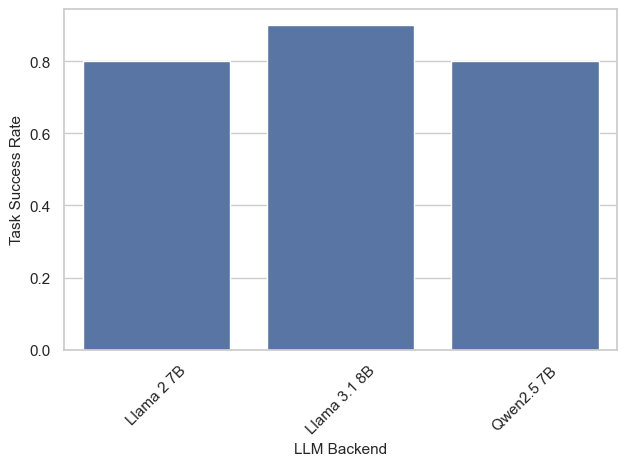

In [56]:
# Ensure Workflow_succes is numeric (0/1)
df_original["Workflow_succes"] = df_original["Workflow_succes"].astype(int)

# Compute success rate per LLM backend
success_rate = (
    df_original.groupby("LLM_backend")["Workflow_succes"]
    .mean()
    .reset_index()
)

success_rate.rename(columns={"Workflow_succes": "Success_rate"}, inplace=True)

print(success_rate)

plt.figure()
sns.barplot(
    data=success_rate,
    x="LLM_backend",
    y="Success_rate"
)

plt.xlabel("LLM Backend")
plt.ylabel("Task Success Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_task_success_rate.png", bbox_inches="tight")
plt.show()

### **2. Workflow outcome per LLM**

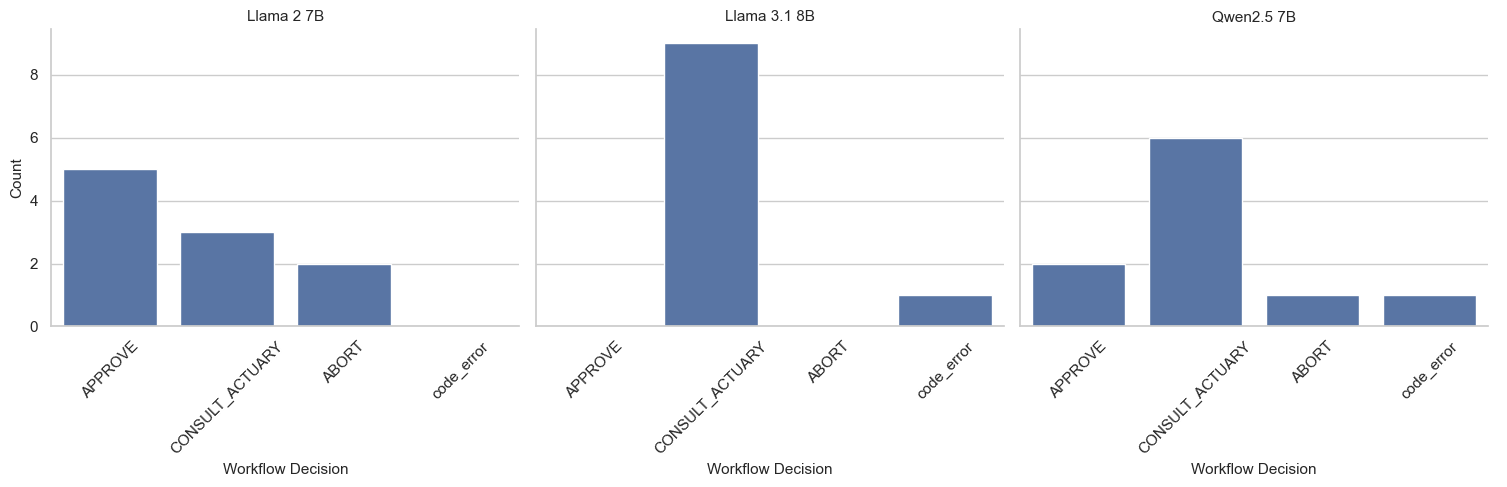

In [57]:
g = sns.catplot(
    data=df_original,
    x="Workflow_decision",
    col="LLM_backend",
    kind="count",
    col_wrap=len(df_original["LLM_backend"].unique()),
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("Workflow Decision", "Count")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("fig_workflow_decisions.png", bbox_inches="tight")
plt.show()

UpSet plot

In [4]:
df_upset = df_original.copy()

df_upset = df_upset[df_upset["LLM_backend"] == "Llama 3.1 8B"]
df_upset["Dataprep_code_success"] = df_upset["Adaptive_dataprep_succes"] == 1
df_upset["Model_code_success"] = df_upset["Adaptive_model_code_succes"] == 1
df_upset["Workflow_decision_APPROVE"] = df_upset["Workflow_decision"] == "APPROVE"
df_upset["Workflow_decision_CONSULT_ACTUARY"] = df_upset["Workflow_decision"] == "CONSULT_ACTUARY"
df_upset["Workflow_decision_ABORT"] = df_upset["Workflow_decision"] == "ABORT"
df_upset["Code_error"] = df_upset["Workflow_decision"] == "code_error"

c:\Users\bart_\anaconda3\envs\thesis_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\bart_\anaconda3\envs\thesis_env\lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

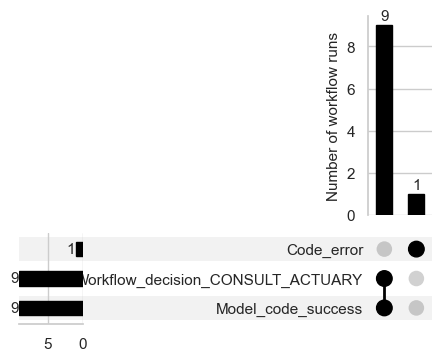

In [5]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

columns = [
    "Dataprep_code_success",
    "Model_code_success",
    "Workflow_decision_APPROVE",
    "Workflow_decision_CONSULT_ACTUARY",
    "Workflow_decision_ABORT",
    "Code_error"
]

data = from_indicators(columns, df_upset)

upset = UpSet(
            data,
            subset_size="count",
            show_counts=True,
            sort_by="cardinality"
        )

fig = plt.figure(figsize=(15,6))
axes = upset.plot(fig=fig)
axes["intersections"].set_ylabel("Number of workflow runs")
axes["intersections"].set_xticks(range(len(upset.intersections)))
axes["intersections"].set_xticklabels(range(1, len(upset.intersections)+1))

plt.tight_layout()
plt.savefig("fig_upset_workflow_success_llama3.1.png", bbox_inches="tight")
plt.show()

### **3. Model choice per LLM**

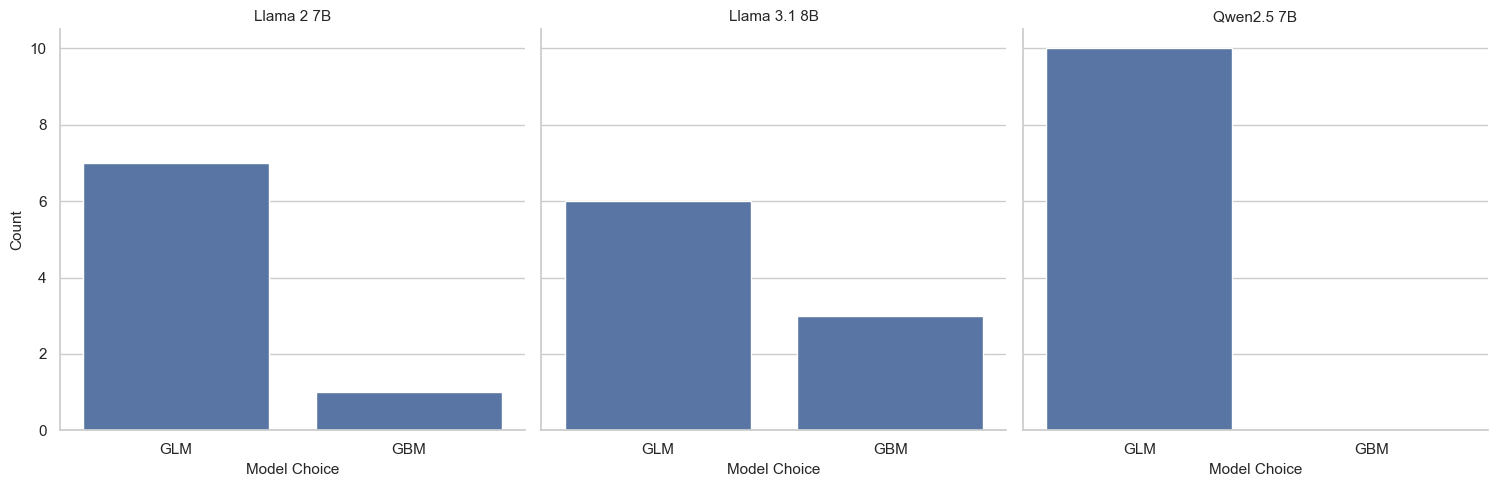

In [60]:
g = sns.catplot(
    data=df_original,
    x="Model_choice",
    col="LLM_backend",
    kind="count",
    col_wrap=len(df_original["LLM_backend"].unique()),
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("Model Choice", "Count")
g.set_titles("{col_name}")

#for ax in g.axes.flatten():
 #   ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("fig_model_choice.png", bbox_inches="tight")
plt.show()

### **4. Model RMSE per LLM**

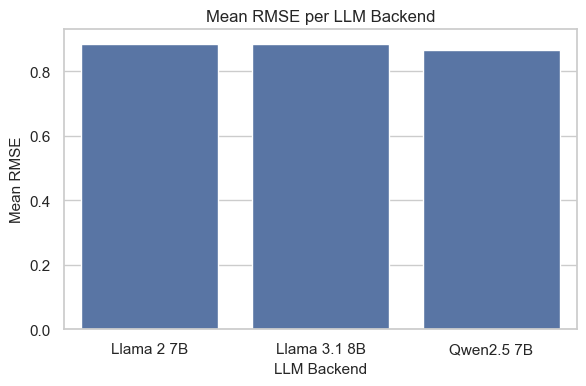

In [61]:
performance_summary = (
    df_original.groupby("LLM_backend")
      .agg({
          "RMSE": "mean",
          "MAE": "mean",
          "Poisson_deviance": "mean"
      })
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=performance_summary,
    x="LLM_backend",
    y="RMSE"
)

plt.title("Mean RMSE per LLM Backend")
plt.xlabel("LLM Backend")
plt.ylabel("Mean RMSE")
plt.tight_layout()
plt.savefig("fig_mean_rmse_per_backend.png", bbox_inches="tight")
plt.show()

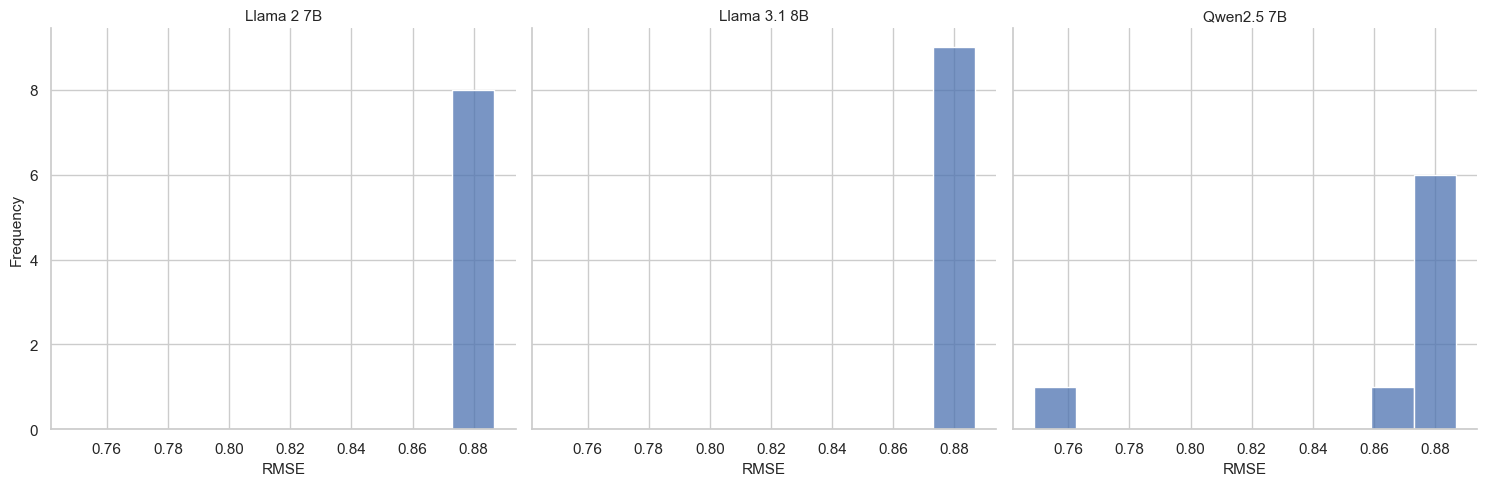

In [62]:
g = sns.displot(
    data=df_original,
    x="RMSE",
    col="LLM_backend",
    col_wrap=len(df_original["LLM_backend"].unique()), 
    bins=10,
    height=5,
    aspect=1,
    facet_kws={"sharey": True}
)

g.set_axis_labels("RMSE", "Frequency")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig("fig_rmse_dist_per_backend.png", bbox_inches="tight")
plt.show()

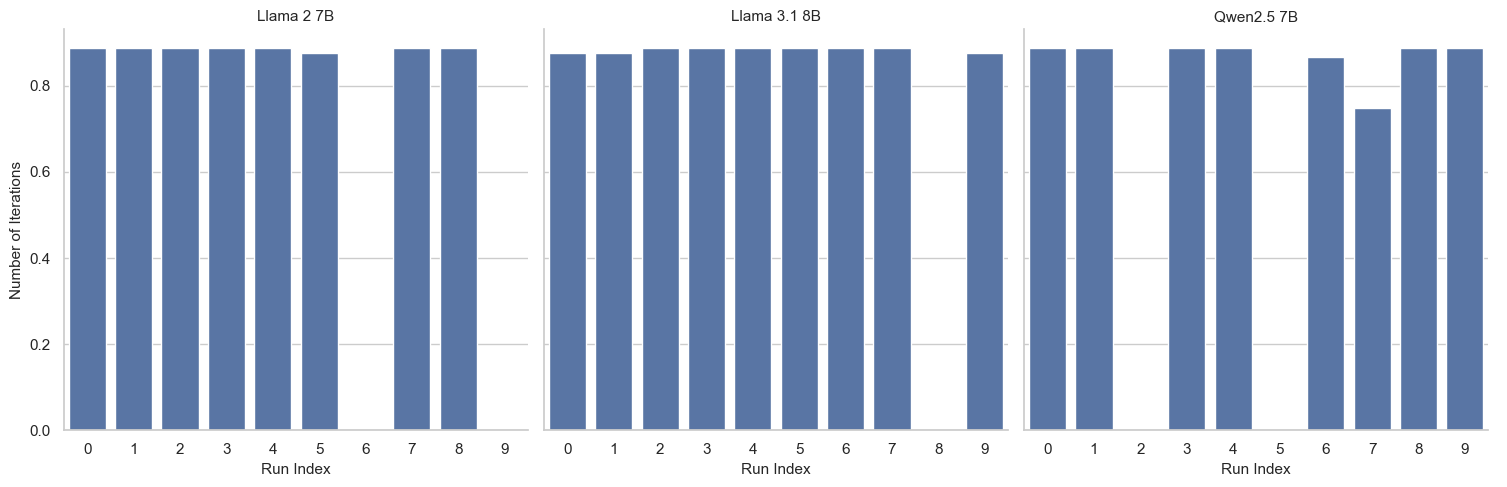

In [63]:
# Ensure numeric
df_original["RMSE"] = pd.to_numeric(
    df_original["RMSE"], errors="coerce"
)

# Create run index per backend (like your reset_index)
df_plot = (
    df_original
    .sort_values(["LLM_backend"])
    .copy()
)

df_plot["Run_Index"] = (
    df_plot.groupby("LLM_backend")
    .cumcount()
)

# Faceted bar plot
g = sns.catplot(
    data=df_plot,
    x="Run_Index",
    y="RMSE",
    col="LLM_backend",
    kind="bar",
    sharey=True
)

g.set_axis_labels("Run Index", "Number of Iterations")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig("fig_rmse_consistency.png", bbox_inches="tight")
plt.show()

Combination of RMSE boxplots and model choice

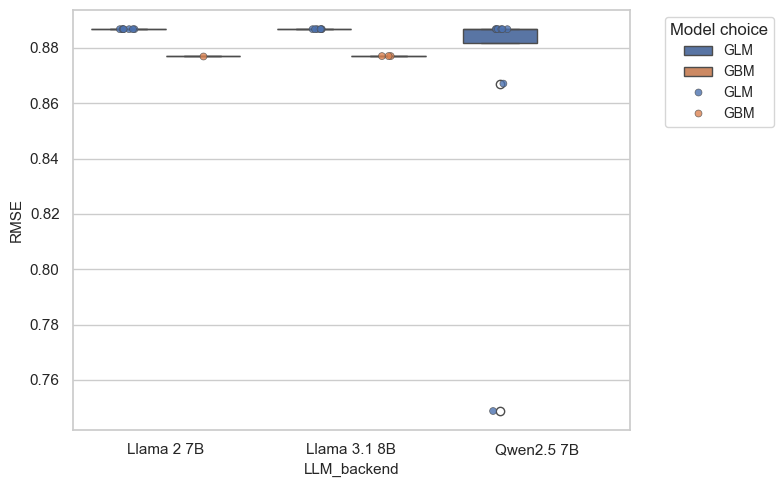

In [69]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_plot,
    x="LLM_backend",
    y="RMSE",
    hue="Model_choice",
    dodge=True
)

sns.stripplot(
    data=df_plot,
    x="LLM_backend",
    y="RMSE",
    hue="Model_choice",
    dodge=True,
    alpha=0.8,
    linewidth=0.5
)

plt.legend(title="Model choice", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("fig_rmse_model_boxplots.png", bbox_inches="tight")
plt.show()

### **5. Code generation success**

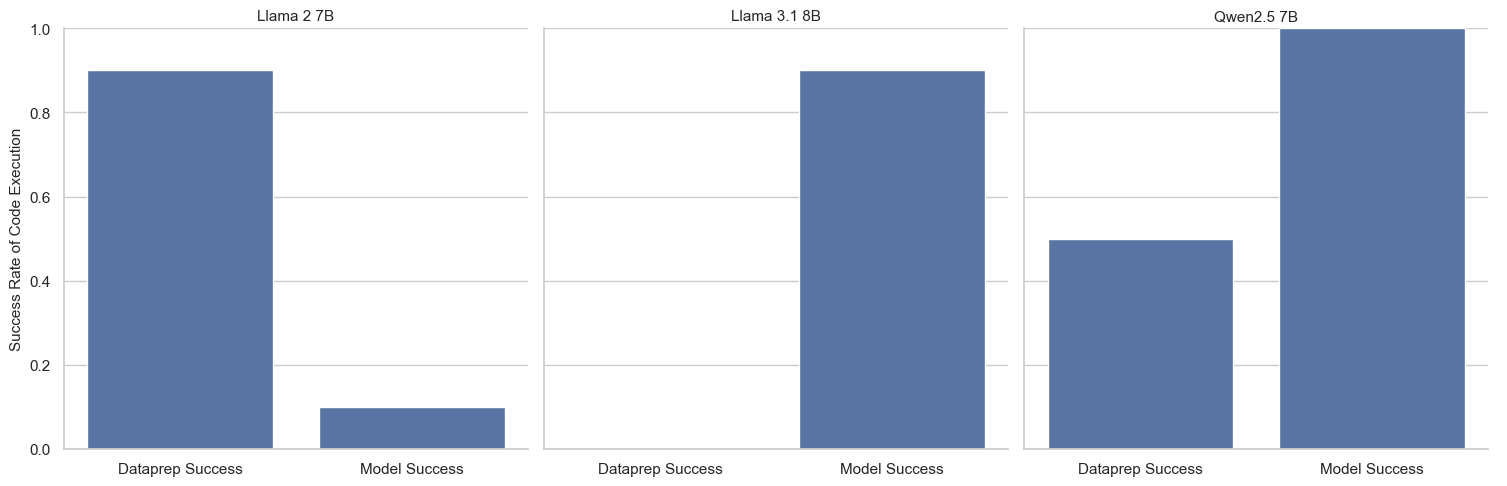

In [21]:
# Ensure success columns are numeric
df_original["Adaptive_dataprep_succes"] = pd.to_numeric(
    df_original["Adaptive_dataprep_succes"], errors="coerce"
)
df_original["Adaptive_model_code_succes"] = pd.to_numeric(
    df_original["Adaptive_model_code_succes"], errors="coerce"
)

# Compute mean success rates per backend
success_rates = (
    df_original
    .groupby("LLM_backend")[[
        "Adaptive_dataprep_succes",
        "Adaptive_model_code_succes"
    ]]
    .mean()
    .reset_index()
)

# Reshape to long format for seaborn
success_long = success_rates.melt(
    id_vars="LLM_backend",
    var_name="Task",
    value_name="Success_rate"
)

# Clean task names
success_long["Task"] = success_long["Task"].replace({
    "Adaptive_dataprep_succes": "Dataprep Success",
    "Adaptive_model_code_succes": "Model Success"
})

# Faceted bar plot
g = sns.catplot(
    data=success_long,
    x="Task",
    y="Success_rate",
    col="LLM_backend",
    kind="bar",
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("", "Success Rate of Code Execution")
g.set_titles("{col_name}")
g.set(ylim=(0, 1))

plt.tight_layout()
plt.savefig("fig_code_execution_success.png", bbox_inches="tight")
plt.show()

### **6. Number of iterations per run, per LLM backend**

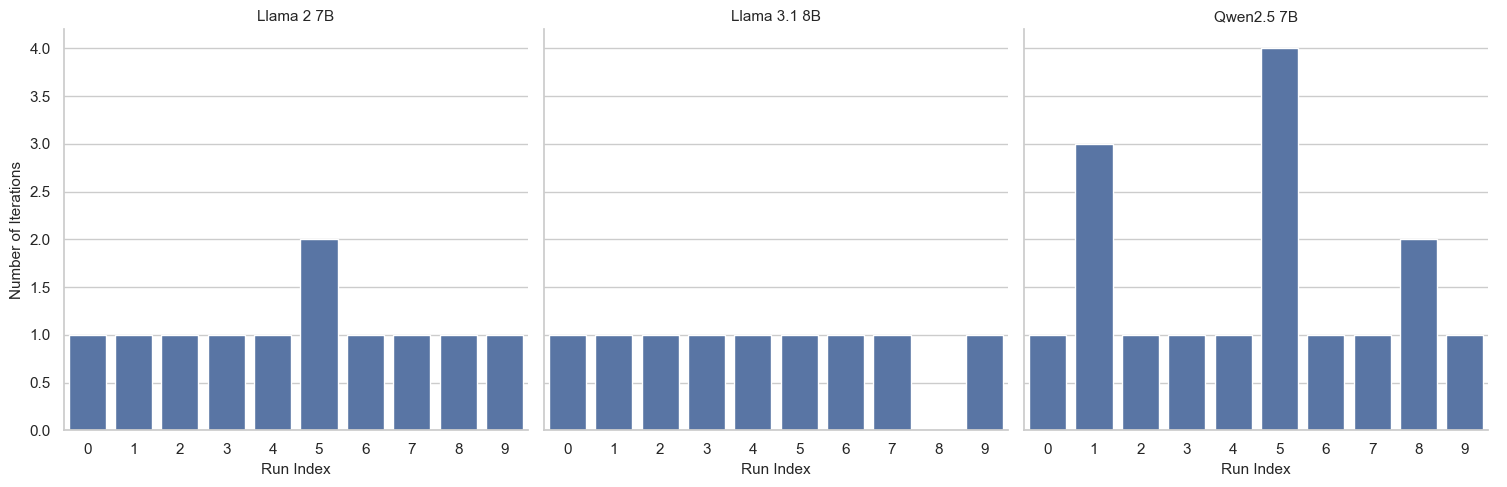

In [22]:
# Ensure numeric
df_original["Iterations"] = pd.to_numeric(
    df_original["Iterations"], errors="coerce"
)

# Create run index per backend (like your reset_index)
df_plot = (
    df_original
    .sort_values(["LLM_backend"])
    .copy()
)

df_plot["Run_Index"] = (
    df_plot.groupby("LLM_backend")
    .cumcount()
)

# Faceted bar plot
g = sns.catplot(
    data=df_plot,
    x="Run_Index",
    y="Iterations",
    col="LLM_backend",
    kind="bar",
    sharey=True
)

g.set_axis_labels("Run Index", "Number of Iterations")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig("fig_iterations_per_backend.png", bbox_inches="tight")
plt.show()

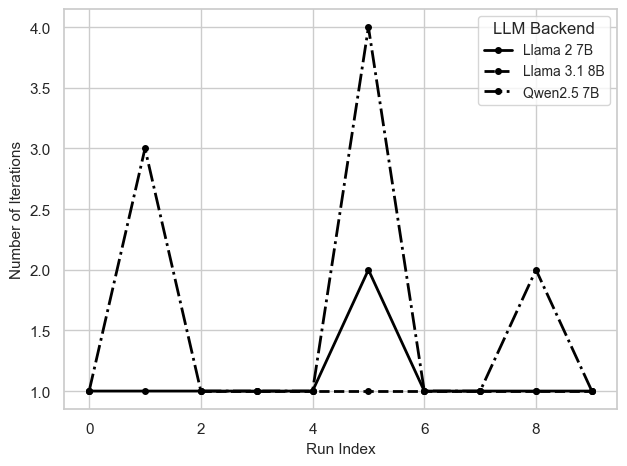

In [72]:
df_plot = df_original.copy()
df_plot["Iterations"] = pd.to_numeric(df_plot["Iterations"], errors="coerce")

# Run index per backend
df_plot["Run_Index"] = df_plot.groupby("LLM_backend").cumcount()

plt.figure()

# Define line styles
line_styles = ["-", "--", "-.", ":"]

backends = sorted(df_plot["LLM_backend"].unique())

for i, backend in enumerate(backends):

    subset = df_plot[
        df_plot["LLM_backend"] == backend
    ].sort_values("Run_Index")

    plt.plot(
        subset["Run_Index"],
        subset["Iterations"],
        linestyle=line_styles[i % len(line_styles)],
        color="black",
        linewidth=2,
        marker="o",
        markersize=4,
        label=backend
    )

plt.xlabel("Run Index")
plt.ylabel("Number of Iterations")

plt.legend(title="LLM Backend")
plt.savefig("fig_iterations_trajectory.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

### **7. BN uncertainty outcome**

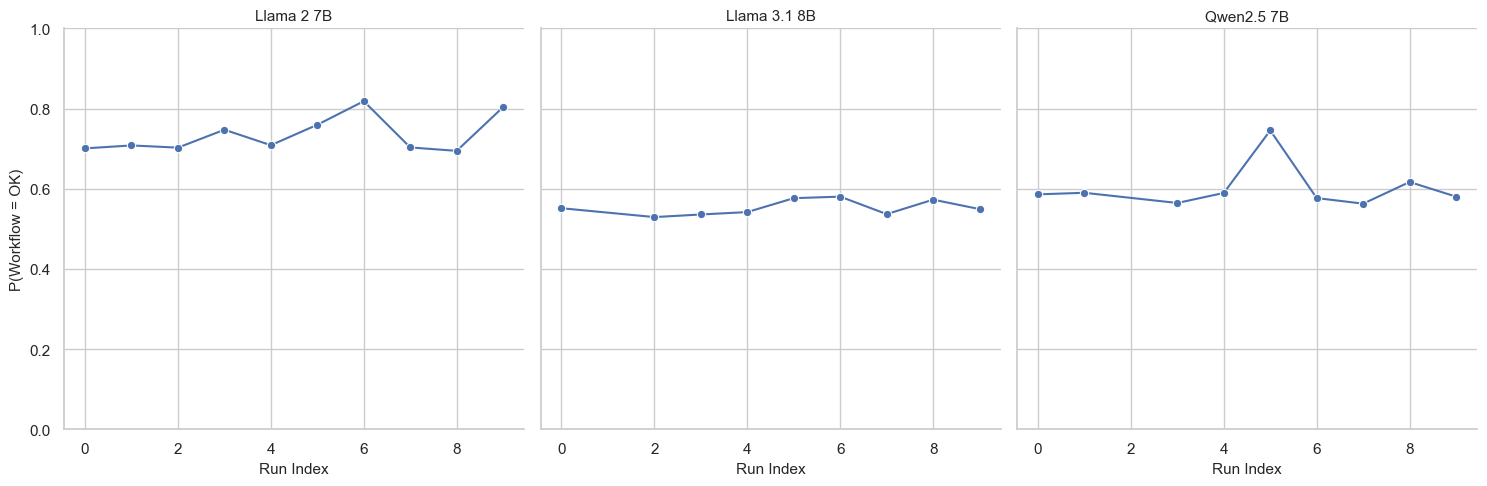

In [23]:
# Ensure numeric (handles NaN safely)
df_original["P(Workflow=OK)"] = pd.to_numeric(
    df_original["P(Workflow=OK)"], errors="coerce"
)

# Create run index per backend (like reset_index in your loop)
df_plot = df_original.copy()
df_plot["Run_Index"] = (
    df_plot
    .groupby("LLM_backend")
    .cumcount()
)

# Faceted line plot
g = sns.relplot(
    data=df_plot,
    x="Run_Index",
    y="P(Workflow=OK)",
    col="LLM_backend",
    kind="line",
    marker="o",
    col_wrap=len(df_plot["LLM_backend"].unique()),
    height=5,
    aspect=1,
    facet_kws={"sharey": True}
)

g.set_axis_labels("Run Index", "P(Workflow = OK)")
g.set_titles("{col_name}")
g.set(ylim=(0, 1))

plt.tight_layout()
plt.savefig("fig_uncertainty_per_backend.png", bbox_inches="tight")
plt.show()

## **Adaptability tests**

In [9]:
# Inspect columns
print(df_test.columns)
df_test.head()

Index(['RunID', 'Timestamp', 'LLM_backend', 'Dataset', 'Workflow_succes',
       'Workflow_decision', 'Iterations', 'Adaptive_dataprep_succes',
       'Model_choice', 'Adaptive_model_code_succes', 'Belief_assessment',
       'TCAV_assessment', 'Fairness_assessment', 'RMSE', 'MAE',
       'Poisson_deviance', 'P(Workflow=OK)', 'Comment', 'Error_detected',
       'Decision_dataprep_review', 'Decision_model_review', 'sparsity',
       'sparsity_numeric', 'row_change', 'column_change', 'missing_rate',
       'target_shift', 'population_shift', 'correlation_shift',
       'severity_score'],
      dtype='object')


,RunID,Timestamp,LLM_backend,Dataset,Workflow_succes,Workflow_decision,Iterations,Adaptive_dataprep_succes,Model_choice,Adaptive_model_code_succes,...,Decision_model_review,sparsity,sparsity_numeric,row_change,column_change,missing_rate,target_shift,population_shift,correlation_shift,severity_score
0,32,20260216_142602,Llama 2 7B,Test_T1,1,CONSULT_ACTUARY,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.094551,0.129366,0.000000,0.000000,0.008308,0.000000,5.750045e-07,0.001572,0.001573
1,33,20260216_181131,Llama 2 7B,Test_T2,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.127942,0.129366,0.000000,0.000000,0.041698,0.000000,4.705761e-06,0.003475,0.003480
2,34,20260216_190533,Llama 2 7B,Test_T3,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.086243,0.129365,0.029498,0.000000,0.000000,0.000057,2.350667e-07,0.001652,0.001710
3,35,20260217_071348,Llama 2 7B,Test_T4,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.086247,0.129370,0.147490,0.000000,0.000000,0.000812,1.689517e-06,0.004710,0.005523
4,36,20260223_133530,Llama 2 7B,Test_T5,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.086342,0.135681,0.000000,0.083333,0.000000,0.000000,0.000000e+00,0.000000,0.000000


### **8. Mean RMSE of test runs**

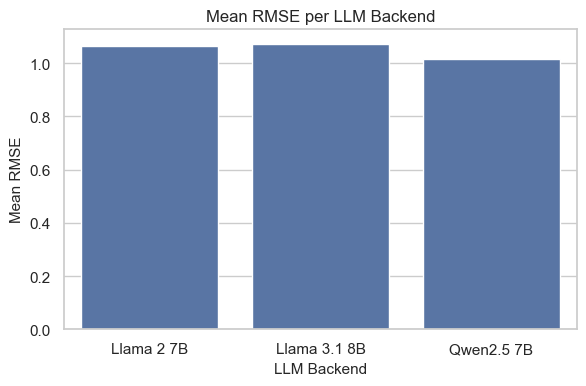

In [10]:
performance_summary = (
    df_test.groupby("LLM_backend")
      .agg({
          "RMSE": "mean",
          "MAE": "mean",
          "Poisson_deviance": "mean"
      })
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=performance_summary,
    x="LLM_backend",
    y="RMSE"
)

plt.title("Mean RMSE per LLM Backend")
plt.xlabel("LLM Backend")
plt.ylabel("Mean RMSE")
plt.tight_layout()
plt.savefig("fig_mean_rmse_per_backend_test.png", bbox_inches="tight")
plt.show()

### **9. Error detection versus test severity**

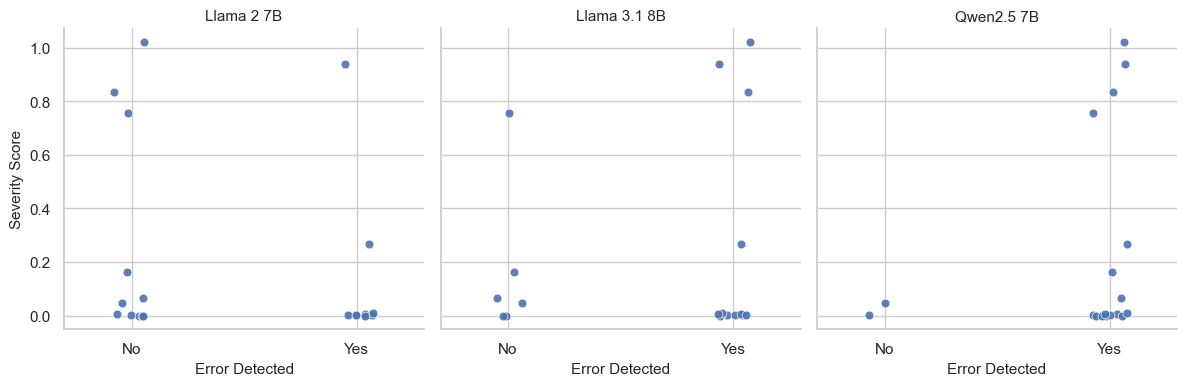

In [11]:
# For visualibility
df_test["Error_random"] = (
    df_test["Error_detected"] +
    np.random.uniform(-0.08, 0.08, size=len(df_test))
)

g = sns.FacetGrid(
    df_test,
    col="LLM_backend",
    col_order=df_test["LLM_backend"].unique(),
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Error_random",
    y="severity_score",
    alpha=0.9,
    s=40
)

g.set_axis_labels("Error Detected", "Severity Score")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlim(-0.3, 1.3)

plt.tight_layout()
plt.savefig("fig_error_detected_severity_scatter.png", bbox_inches="tight")
plt.show()

### **10. Review decision when error was detected, versus test severity**

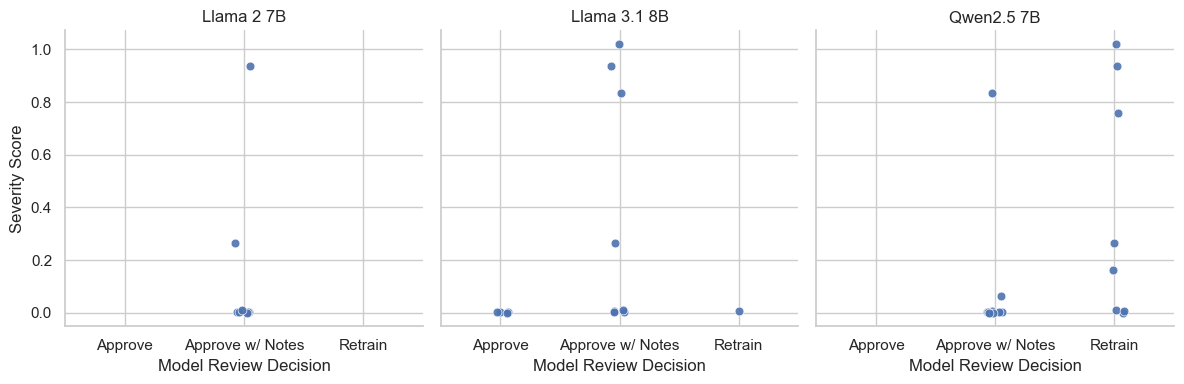

In [12]:
sns.set_theme(style="whitegrid")

# Filter to detected errors
df_detected = df_test[df_test["Error_detected"] == 1].copy()

# Ensure ordered categories (important!)
decision_order = [
    "APPROVE",
    "APPROVE_WITH_NOTES",
    "RETRAIN"
]

df_detected["Decision_model_review"] = pd.Categorical(
    df_detected["Decision_model_review"],
    categories=decision_order,
    ordered=True
)

# Add horizontal jitter
df_detected["Decision_numeric"] = df_detected["Decision_model_review"].cat.codes
df_detected["Decision_jitter"] = (
    df_detected["Decision_numeric"] +
    np.random.uniform(-0.08, 0.08, size=len(df_detected))
)

# Faceted scatter
g = sns.FacetGrid(
    df_detected,
    col="LLM_backend",
    col_order=df_test["LLM_backend"].unique(),
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Decision_jitter",
    y="severity_score",
    alpha=0.9,
    s=40
)

g.set_axis_labels("Model Review Decision", "Severity Score")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([
        "Approve",
        "Approve w/ Notes",
        "Retrain"
    ])
    ax.set_xlim(-0.5, 2.5)

plt.tight_layout()
plt.savefig("fig_severity_model_review_scatter.png", bbox_inches="tight")
plt.show()

Upset plot

In [25]:
df_upset = df_test[df_test["LLM_backend"] == "Qwen2.5 7B"]

# Binary indicators
df_upset["Error_detected"] = df_upset["Error_detected"] == 1

# Severity category
df_upset["High_severity"] = df_upset["severity_score"] >= 0.7

# Model decisions
df_upset["Approve"] = df_upset["Decision_model_review"] == "APPROVE"
df_upset["Approve_notes"] = df_upset["Decision_model_review"] == "APPROVE_WITH_NOTES"
df_upset["Retrain"] = df_upset["Decision_model_review"] == "RETRAIN"    

C:\Users\bart_\AppData\Local\Temp\ipykernel_29096\3592876154.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_upset["Error_detected"] = df_upset["Error_detected"] == 1
C:\Users\bart_\AppData\Local\Temp\ipykernel_29096\3592876154.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_upset["High_severity"] = df_upset["severity_score"] >= 0.7
C:\Users\bart_\AppData\Local\Temp\ipykernel_29096\3592876154.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

c:\Users\bart_\anaconda3\envs\thesis_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\bart_\anaconda3\envs\thesis_env\lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

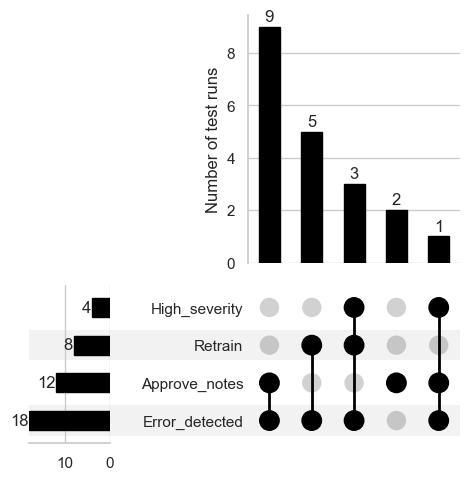

In [27]:
from upsetplot import UpSet, from_indicators

columns = [
    "Error_detected",
    "High_severity",
    "Approve",
    "Approve_notes",
    "Retrain"
]

data = from_indicators(columns, df_upset)

upset = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality",
    element_size=40
)

fig = plt.figure(figsize=(10,6))
axes = upset.plot(fig=fig)

axes["intersections"].set_ylabel("Number of test runs")

plt.tight_layout()
plt.savefig("fig_upset_test_runs_qwen.png", bbox_inches="tight")
plt.show()

In [ ]:
decision_order = ["APPROVE", "APPROVE_WITH_NOTES", "RETRAIN"]

df_plot = df_test.copy()

df_plot["Decision_model_review"] = pd.Categorical(
    df_plot["Decision_model_review"],
    categories=decision_order,
    ordered=True
)

df_plot["Decision_numeric"] = df_plot["Decision_model_review"].cat.codes

df_plot["Decision_jitter"] = (
    df_plot["Decision_numeric"] +
    np.random.uniform(-0.1, 0.1, size=len(df_plot))
)

df_plot["Error_jitter"] = (
    df_plot["Error_detected"] +
    np.random.uniform(-0.05, 0.05, size=len(df_plot))
)

In [18]:
df_plot = df_test.copy()

# Create combined outcome
df_plot["Outcome"] = np.where(
    df_plot["Error_detected"] == 0,
    "NO_ERROR_DETECTED",
    "ERROR_DETECTED_" + df_plot["Decision_model_review"].astype(str)
)

# Define correct order
outcome_order = [
    "NO_ERROR_DETECTED",
    "ERROR_DETECTED_APPROVE",
    "ERROR_DETECTED_APPROVE_WITH_NOTES",
    "ERROR_DETECTED_RETRAIN"
]

df_plot["Outcome"] = pd.Categorical(
    df_plot["Outcome"],
    categories=outcome_order,
    ordered=True
)

C:\Users\bart_\AppData\Local\Temp\ipykernel_25372\2226482595.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["LLM_backend", "severity_bin", "Outcome"])


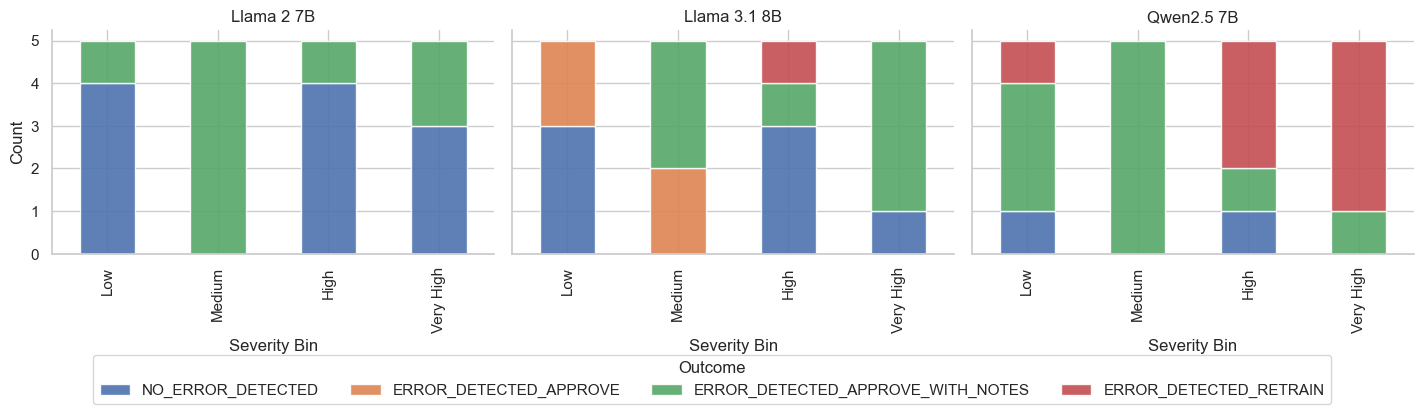

In [20]:
# Bin severity (quantiles work well)
df_plot["severity_bin"] = pd.qcut(
    df_plot["severity_score"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df_counts = (
    df_plot
    .groupby(["LLM_backend", "severity_bin", "Outcome"])
    .size()
    .reset_index(name="count")
)

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_counts,
    col="LLM_backend",
    col_order=df_plot["LLM_backend"].unique(),
    height=4,
    aspect=1.2,
    sharey=True
)

# Store handles globally
legend_handles = None
legend_labels = None

def stacked_bar(data, **kwargs):
    global legend_handles, legend_labels
    
    pivot = data.pivot(
        index="severity_bin",
        columns="Outcome",
        values="count"
    ).fillna(0)

    pivot = pivot[outcome_order]

    ax = plt.gca()
    
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        alpha=0.9,
        legend=False  # 🔥 IMPORTANT: disable per-plot legend
    )
    
    # Capture legend info once
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

g.map_dataframe(stacked_bar)

g.set_axis_labels("Severity Bin", "Count")
g.set_titles("{col_name}")

# --- Add ONE shared legend ---
g.fig.legend(
    legend_handles,
    legend_labels,
    title="Outcome",
    loc="lower center",          # 👈 change to "upper center" if preferred
    ncol=len(outcome_order),
    bbox_to_anchor=(0.5, -0.05)  # 👈 move below plot
)

# Adjust layout to make space for legend
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("fig_stacked_severity_outcomes.png", bbox_inches="tight")
plt.show()

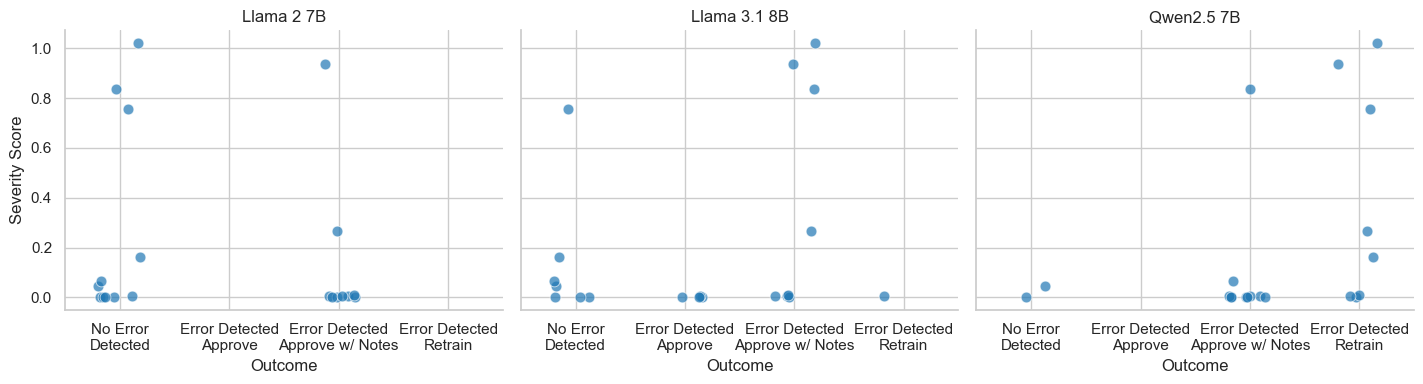

In [25]:
df_plot = df_test.copy()

# --- Create combined outcome ---
df_plot["Outcome"] = np.where(
    df_plot["Error_detected"] == 0,
    "NO_ERROR",
    "YES_" + df_plot["Decision_model_review"].astype(str)
)

outcome_order = [
    "NO_ERROR",
    "YES_APPROVE",
    "YES_APPROVE_WITH_NOTES",
    "YES_RETRAIN"
]

df_plot["Outcome"] = pd.Categorical(
    df_plot["Outcome"],
    categories=outcome_order,
    ordered=True
)

# --- Numeric encoding for jitter ---
df_plot["Outcome_numeric"] = df_plot["Outcome"].cat.codes

# Jitter ONLY on x-axis
df_plot["Outcome_jitter"] = (
    df_plot["Outcome_numeric"] +
    np.random.uniform(-0.2, 0.2, size=len(df_plot))
)

# --- Plot ---
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_plot,
    col="LLM_backend",
    col_order=df_plot["LLM_backend"].unique(),
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Outcome_jitter",
    y="severity_score",
    #hue="Outcome",
    color="tab:blue",
    alpha=0.7,
    s=60
)

g.set_axis_labels("Outcome", "Severity Score")
g.set_titles("{col_name}")

# --- Axis formatting ---
for ax in g.axes.flat:
    ax.set_xticks(range(len(outcome_order)))
    ax.set_xticklabels([
    "No Error\nDetected",
    "Error Detected\nApprove",
    "Error Detected\nApprove w/ Notes",
    "Error Detected\nRetrain"
])

    ax.set_xlim(-0.5, len(outcome_order) - 0.5)

# Legend (shared)
#g.add_legend(title="Outcome")

plt.tight_layout()
plt.savefig("fig_scatter_outcome_vs_severity.png", bbox_inches="tight")
plt.show()

### **11. Compare (un)certainty scores over test severity**

C:\Users\bart_\AppData\Local\Temp\ipykernel_29096\620159946.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["severity_bin", "LLM_backend"])


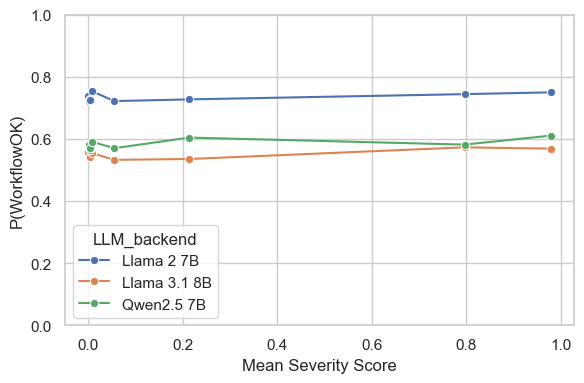

In [13]:
# Create severity deciles
df_test["severity_bin"] = pd.qcut(
    df_test["severity_score"],
    q=10,
    duplicates="drop"
)

summary = (
    df_test
    .groupby(["severity_bin", "LLM_backend"])
    .agg(
        mean_severity=("severity_score", "mean"),
        prob_workflowok=("P(Workflow=OK)", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=summary,
    x="mean_severity",
    y="prob_workflowok",
    hue="LLM_backend",
    marker="o"
)

plt.xlabel("Mean Severity Score")
plt.ylabel("P(WorkflowOK)")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("fig_workflowok_probability_test.png", bbox_inches="tight")
plt.show()

### **12. Plot distributions of the explanation assessments and compare to Original runs (only for Qwen)**

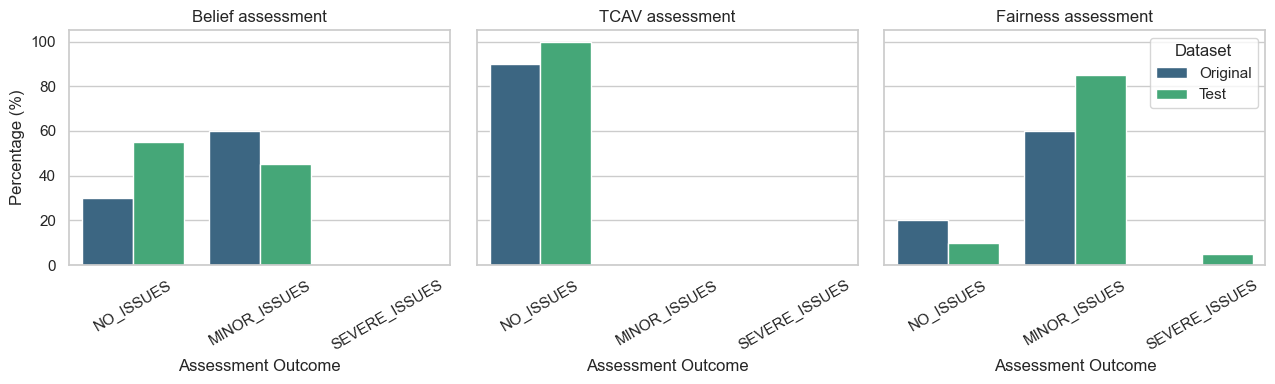

In [14]:
assessment_categories = ["NO_ISSUES", "MINOR_ISSUES", "SEVERE_ISSUES"]
assessment_cols = ["Belief_assessment", "TCAV_assessment", "Fairness_assessment"]

# Filter backend if needed
df_test_qwen = df_test[df_test["LLM_backend"] == "Qwen2.5 7B"].copy()
df_original_qwen = df_original[df_original["LLM_backend"] == "Qwen2.5 7B"].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# Dataset sizes (for normalization)
n_test = len(df_test_qwen)
n_original = len(df_original_qwen)

for ax, col in zip(axes, assessment_cols):

    # Count distributions
    test_counts = (
        df_test_qwen[col]
        .dropna()
        .value_counts()
        .reindex(assessment_categories, fill_value=0)
    )

    original_counts = (
        df_original_qwen[col]
        .dropna()
        .value_counts()
        .reindex(assessment_categories, fill_value=0)
    )

    # Convert to percentages
    test_pct = 100 * test_counts / n_test if n_test > 0 else test_counts * 0
    original_pct = 100 * original_counts / n_original if n_original > 0 else original_counts * 0

    # Build plot dataframe (Original first, then Test)
    plot_df = pd.DataFrame({
        "Outcome": list(assessment_categories) * 2,
        "Dataset": ["Original"] * len(assessment_categories) +
                ["Test"] * len(assessment_categories),
        "Percentage": list(original_pct.values) + list(test_pct.values)
    })

    sns.barplot(
        data=plot_df,
        x="Outcome",
        y="Percentage",
        hue="Dataset",
        hue_order=["Original", "Test"],
        palette="viridis",
        ax=ax
    )

    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Assessment Outcome")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis='x', rotation=30)

    if ax != axes[-1]:
        ax.legend_.remove()

plt.tight_layout()

plt.savefig("fig_qwen_assessment_distributions.png", bbox_inches="tight")
plt.show()

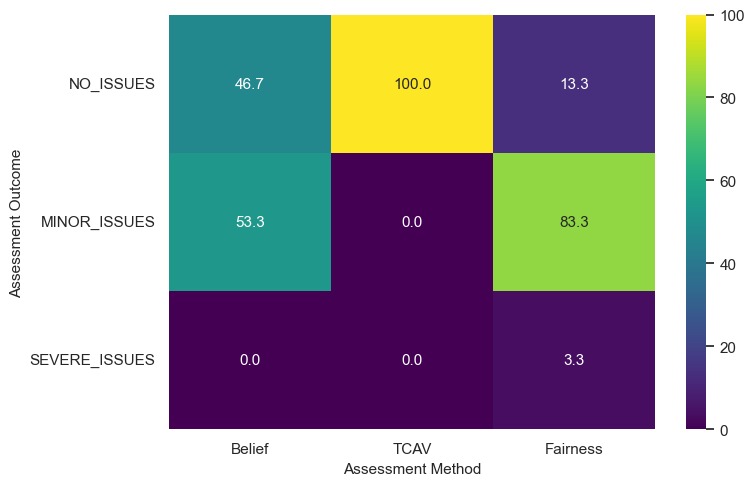

In [3]:
assessment_categories = ["NO_ISSUES", "MINOR_ISSUES", "SEVERE_ISSUES"]
assessment_cols = ["Belief_assessment", "TCAV_assessment", "Fairness_assessment"]

# ------------------------------
# Filter backend datasets
# ------------------------------
df_test_qwen = df_test[df_test["LLM_backend"] == "Qwen2.5 7B"].copy()
df_original_qwen = df_original[df_original["LLM_backend"] == "Qwen2.5 7B"].copy()

# Add dataset label (optional but good practice)
df_test_qwen["dataset"] = "Test"
df_original_qwen["dataset"] = "Original"

# ------------------------------
# Concatenate datasets first
# ------------------------------
df_combined = pd.concat(
    [df_original_qwen, df_test_qwen],
    ignore_index=True
)

n_total = len(df_combined)

# ------------------------------
# Build heatmap matrix directly from combined dataset
# ------------------------------
heat_matrix = pd.DataFrame(
    index=assessment_categories,
    columns=assessment_cols
)

for col in assessment_cols:
    counts = (
        df_combined[col]
        .dropna()
        .value_counts()
        .reindex(assessment_categories, fill_value=0)
    )
    heat_matrix[col] = 100 * counts / n_total if n_total > 0 else 0

# ------------------------------
# Plot heatmap
# ------------------------------
plt.figure(figsize=(8, 5))

ax = sns.heatmap(
    heat_matrix,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    vmin=0,
    vmax=100
)

plt.xlabel("Assessment Method")
plt.ylabel("Assessment Outcome")

# X-axis labels → center under columns
plt.xticks(
    ticks=[i + 0.5 for i in range(len(assessment_cols))],
    labels=[c.replace("_assessment", "") for c in assessment_cols],
    rotation=0,
    ha="center"
)

# Y-axis labels → horizontal
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("fig_qwen_combined_heatmap.png", bbox_inches="tight")
plt.show()

### **13. Estimate which test characteristics had the most effect on triggering the error detection**

In [15]:
# Test dataset features to use
FEATURES = [
    "sparsity",
    "row_change",
    "column_change",
    "missing_rate",
    "target_shift",
    "population_shift",
    "correlation_shift"
]

TARGET = "Error_detected"

# Clean dataset copy
df_model = df_test.copy()

# Convert percentage-like columns if stored as strings
for col in FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Drop missing values
df_model = df_model.dropna(subset=FEATURES + [TARGET, "LLM_backend"])

# Container for results
importance_results = {}

# Train model per backend
for backend in df_model["LLM_backend"].unique():

    df_backend = df_model[df_model["LLM_backend"] == backend]

    if len(df_backend) < 10:
        continue  # avoid unstable models

    X = df_backend[FEATURES]
    y = df_backend[TARGET]

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Logistic regression (L2 regularized)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, y)

    # Feature importance = absolute standardized coefficient
    importance = pd.Series(
        np.abs(model.coef_[0]),
        index=FEATURES
    ).sort_values(ascending=False)

    importance_results[backend] = importance

# Convert to dataframe
importance_df = pd.DataFrame(importance_results)

print("\n=== Feature Importance by Backend ===")
print(importance_df)


=== Feature Importance by Backend ===
                   Llama 2 7B  Llama 3.1 8B  Qwen2.5 7B
column_change        0.505987      0.877137    0.312933
correlation_shift    1.051272      0.567362    0.286082
missing_rate         0.368830      0.427057    0.080276
population_shift     0.720677      0.861050    0.823433
row_change           0.612892      0.296002    0.017477
sparsity             0.121833      0.112177    0.155445
target_shift         0.317953      0.777789    0.216709


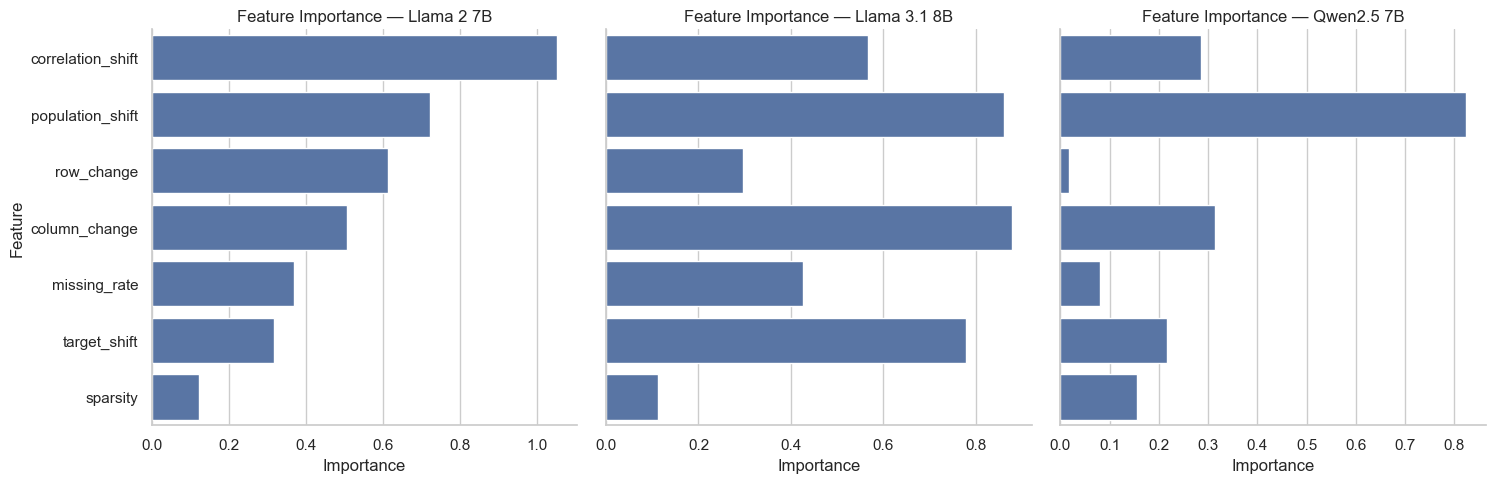

In [16]:
# Select up to 3 backends
backend_list = importance_df.columns[:3]

# Convert to long format
importance_long = (
    importance_df[backend_list]
    .abs()
    .reset_index()
    .melt(id_vars="index",
        var_name="LLM_backend",
        value_name="Importance")
    .rename(columns={"index": "Feature"})
)

# Sort features within each backend
importance_long = (
    importance_long
    .sort_values(["LLM_backend", "Importance"], ascending=[True, False])
)

# Faceted horizontal bar plot
g = sns.catplot(
    data=importance_long,
    y="Feature",
    x="Importance",
    col="LLM_backend",
    kind="bar",
    sharex=False,
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("Importance", "Feature")
g.set_titles("Feature Importance — {col_name}")
g.fig.tight_layout()

plt.savefig("fig_feature_importance.png", bbox_inches="tight")
plt.show()

Beeswarm plot (only for Qwen model):

In [40]:
import shap

backend = backend_list[2]  # example: first backend
df_backend = df_model[df_model["LLM_backend"] == backend]

X = df_backend[FEATURES]
y = df_backend[TARGET]

scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=FEATURES,
    index=X.index
)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# SHAP explainer for linear model
explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_scaled)

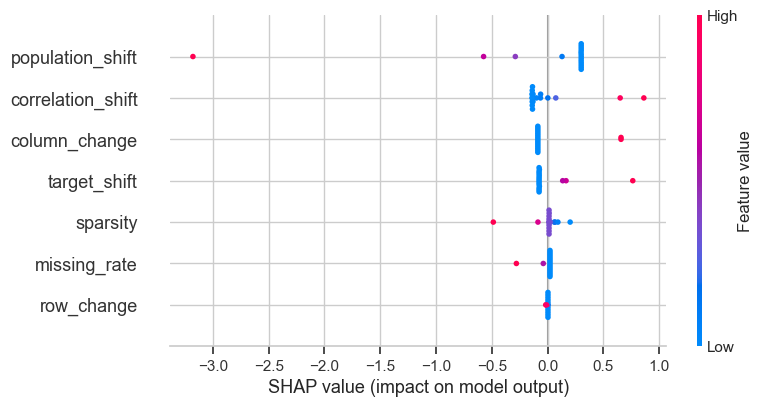

<Figure size 640x480 with 0 Axes>

In [45]:
shap.plots.beeswarm(shap_values, show=True)
plt.savefig("fig_shap_beeswarm.png", dpi=300, bbox_inches="tight")